# Bookended nonresonant lab XRR fit

Port of `bookended_nonres_repl.py`. Transplants the resonant (283.7 eV) graded book-ended ZnPc profile onto a Cu-K\(\alpha\) (8.04 keV) lab XRR dataset and refits against the data. For now the free film parameters are `total_thick`, book-end interface densities (`density_vac`, `density_si`), Oxide geometry, and instrument nuisance terms; bulk density and orientation stay at the resonant-fit anchors.

Requires `graded_fit_summary.json` from `refl-analysis/scripts/extract_graded_bookended_fit.py` and the lab CSV under `refl-analysis/notebooks/fitting/`.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from refnx.analysis import CurveFitter, Transform

from refloxide.data import ReflectDataset
from refloxide.model import BookendedComponent, MaterialSLD, ReflectModel
from refloxide.objective import Objective
from refloxide.pxr.energy.bookended import BookendedOrientationProfile
from refloxide.pxr.energy.ooc import OocAnchor

## Paths and resonant-fit summary

In [2]:
GRADED_DIR = Path.home() / "projects/refl-analysis/@models/xrr/znpc/graded"
SUMMARY_PATH = GRADED_DIR / "graded_fit_summary.json"
CSV_PATH = (
    Path.home()
    / "projects/refl-analysis/notebooks/fitting/HiRes_BigRegion_ExcelMerge_CSV.csv"
)
for path in (SUMMARY_PATH, CSV_PATH):
    if not path.exists():
        raise FileNotFoundError(
            f"missing {path} -- run scripts/extract_graded_bookended_fit.py in the "
            "refl-analysis venv first (for SUMMARY_PATH), or check the dataset path"
        )

summary = json.loads(SUMMARY_PATH.read_text())
ooc_csv = Path(summary["ooc_csv"])
if not ooc_csv.exists():
    raise FileNotFoundError(f"missing {ooc_csv} referenced by {SUMMARY_PATH}")
ZNPC_OOC = OocAnchor.from_file(ooc_csv)

ENERGY_EV = 8.04e3
_HC_EV_ANGSTROM = 12398.42

print(
    f"resonant reference fit was at {summary['energy']:.1f} eV; refitting at "
    f"{ENERGY_EV:.2f} eV"
)
film_params = summary["film"]["params"]
for name, value in film_params.items():
    print(f"  {name}: {value:.4f}")

resonant reference fit was at 283.7 eV; refitting at 8040.00 eV
  total_thick: 188.7489
  surface_roughness: 8.3733
  tau_si: 16.8996
  tau_vac: 25.0000
  alpha_bulk: 1.2718
  alpha_si: 0.4457
  alpha_vac: 1.0280
  density_bulk: 1.6385
  density_si: 0.8722
  density_vac: 1.9794


## Load lab XRR CSV (angle + intensity \(\rightarrow\) \(q\), \(R\))

Raw detector counts; `scale_s` absorbs the unknown \(I_0\). Peak-normalized \(R\) only seeds `scale_s \(\approx 1\)`.

In [3]:
frame = pl.read_csv(CSV_PATH)
angle_deg = frame["IncidentAngle(deg)"].to_numpy()
intensity = frame["Intensity(a.u.)"].to_numpy()
sigma_i = frame["Sigma_I(a.u.)"].to_numpy()

wavelength = _HC_EV_ANGSTROM / ENERGY_EV
q = (4.0 * np.pi / wavelength) * np.sin(np.radians(angle_deg))
norm = float(intensity.max())
r = intensity / norm
r_err = sigma_i / norm
print(f"wavelength = {wavelength:.4f} A, q range = [{q.min():.4f}, {q.max():.4f}] 1/A")
print(f"{len(q)} points, normalized peak r = {r.max():.4f}")

dataset = ReflectDataset(
    q=q,
    energy=np.full_like(q, ENERGY_EV),
    pol=np.full(q.shape, "s", dtype=object),
    r=r,
    r_err=r_err,
)

wavelength = 1.5421 A, q range = [0.0235, 0.2755] 1/A
124 points, normalized peak r = 1.0000


## Substrate stack helpers, bounds, and discrete-slab seed geometry

`bkg` is pinned (not fit). Oxide roughness upper bound follows the Nevot-Croce ceiling for its frozen thickness. `REFERENCE` seeds `total_thick` start and frozen \(\tau_\mathrm{vac}\)/\(\tau_\mathrm{Si}\). Interface density bounds follow `bookended_real_data_fit.ipynb`.

In [4]:
BKG_ESTIMATE = 0.0

layers = {layer["name"]: layer for layer in summary["layers"]}


def build_slab(
    name: str,
    *,
    vary_rough: bool = False,
    rough_bounds: tuple[float, float] = (0.0, 30.0),
):
    layer = layers[name]
    sld = MaterialSLD(layer["formula"], density=layer["density"], name=name)
    slab = sld(layer["thick"], layer["rough"])
    slab.thick.vary = False
    sld.density.vary = False
    if vary_rough:
        slab.rough.setp(vary=True, bounds=rough_bounds)
    else:
        slab.rough.vary = False
    return slab


def freeze_instrumentation(model: ReflectModel) -> None:
    """Open scale_s/theta_offset_s; fix bkg at the measured floor.

    Call after the first per-energy channel exists (after ReflectModel
    construction). Newly created channels default scale_p/theta_offset_p
    to vary=True with infinite bounds, which breaks differential_evolution.
    """
    model.scale_s.at(ENERGY_EV).setp(vary=True, bounds=(0.8, 1.2))
    model.theta_offset_s.at(ENERGY_EV).setp(vary=True, bounds=(-0.8, 0.8))
    model.bkg.at(ENERGY_EV).value = BKG_ESTIMATE
    model.bkg.at(ENERGY_EV).vary = False
    model.scale_p.at(ENERGY_EV).vary = False
    model.theta_offset_p.at(ENERGY_EV).vary = False


_oxide_thick = layers["Oxide"]["thick"]
_oxide_rough_ceiling = float(np.sqrt(2.0 * np.pi) * _oxide_thick / 2.0)

BOUNDS = {
    "surface_roughness": (3.0, 20.0),
    "oxide_rough": (0.0, _oxide_rough_ceiling),
    "density_vac": (1.5, 2.5),
    "density_si": (0.0, 1.3),
}

REFERENCE = {
    "surface_thick": 7.89151,
    "surface_rough": 6.28961,
    "bulk_thick": 125.596,
    "interface_thick": 18.2626,
    "oxide_thick": 9.84672,
    "oxide_rho": 2.0692,
    "substrate_rough": 0.5,
    "substrate_rho": 2.21255,
}
REFERENCE_TOTAL_THICK = (
    REFERENCE["surface_thick"] + REFERENCE["bulk_thick"] + REFERENCE["interface_thick"]
)
print(f"REFERENCE_TOTAL_THICK = {REFERENCE_TOTAL_THICK:.2f} A")
print(f"oxide rough NC ceiling = {_oxide_rough_ceiling:.2f} A")

REFERENCE_TOTAL_THICK = 151.75 A
oxide rough NC ceiling = 8.62 A


## Graded book-ended model

Orientation and `density_bulk` stay frozen at the resonant fit. Free: `total_thick`, interface densities (`density_vac`, `density_si`), Oxide thick/rough, `scale_s`, `theta_offset_s`. \(\tau\) values are re-seeded from `REFERENCE` and held fixed.

In [5]:
graded_film = BookendedOrientationProfile(
    ooc=ZNPC_OOC,
    energy=summary["energy"],
    num_slabs=summary["film"]["num_slabs"],
    mesh_constant=summary["film"]["mesh_constant"],
    name="ZnPc",
    **film_params,
)
graded_structure = (
    build_slab("Vacuum")
    | BookendedComponent(graded_film)
    | build_slab("Oxide", vary_rough=True, rough_bounds=BOUNDS["oxide_rough"])
    | build_slab("Substrate")
)

graded_model = ReflectModel(graded_structure, parallel=False)
graded_film.total_thick.setp(value=150, vary=True, bounds=(100, 180))
graded_film.surface_roughness.setp(
    value=REFERENCE["surface_rough"], vary=False, bounds=BOUNDS["surface_roughness"]
)
graded_film.tau_vac.setp(value=REFERENCE["surface_thick"], vary=False)
graded_film.tau_si.setp(value=REFERENCE["interface_thick"], vary=False)
graded_film.density_vac.setp(vary=True, bounds=BOUNDS["density_vac"])
graded_film.density_si.setp(vary=True, bounds=BOUNDS["density_si"])
graded_film.density_bulk.vary = False

oxide_slab = graded_structure.slab("Oxide")
oxide_slab.thick.setp(value=REFERENCE["oxide_thick"], vary=True, bounds=(5, 12.0))
oxide_slab.rough.setp(vary=True, bounds=(0, 12))
oxide_slab.sld.density.setp(value=REFERENCE["oxide_rho"], vary=False)

substrate_slab = graded_structure.slab("Substrate")
substrate_slab.rough.value = REFERENCE["substrate_rough"]
substrate_slab.sld.density.value = REFERENCE["substrate_rho"]

freeze_instrumentation(graded_model)

graded_objective = Objective(
    graded_model, dataset, transform=Transform("logY"), nc_constraint=True
)
print(f"free parameters: {len(graded_objective.varying_parameters())}")
print(f"logl before fit: {graded_objective.logl():.3f}")
print(graded_objective.varying_parameters())

free parameters: 7
logl before fit: -5021032.282
________________________________________________________________________________
Parameters:      None      
<Parameter:'scale_s@8040p0eV', value=1          , bounds=[0.8, 1.2]>
<Parameter:'theta_offset_s@8040p0eV', value=0          , bounds=[-0.8, 0.8]>
<Parameter: 'total_thick' , value=150          , bounds=[100.0, 180.0]>
<Parameter: 'density_si'  , value=0.87222          , bounds=[0.0, 1.3]>
<Parameter: 'density_vac' , value=1.97936          , bounds=[1.5, 2.5]>
<Parameter: 'Oxide_thick' , value=9.84672          , bounds=[5.0, 12.0]>
<Parameter: 'Oxide_rough' , value=8.12666          , bounds=[0.0, 12.0]>


## Differential evolution fit

Single-process (`workers` default): each `nll()` is milliseconds; pool startup dominates at this size.

In [6]:
CurveFitter(graded_objective).fit(
    method="differential_evolution", popsize=30, polish=True, seed=1
)
print(f"logl after fit:  {graded_objective.logl():.3f}")
print(f"chisqr after fit: {graded_objective.chisqr():.3f}")
print(f"recovered total_thick        = {graded_film.total_thick.value:.2f} A")
print(f"recovered surface_roughness  = {graded_film.surface_roughness.value:.2f} A")
print(f"recovered oxide thick        = {oxide_slab.thick.value:.2f} A")
print(f"recovered oxide rough        = {oxide_slab.rough.value:.2f} A")
print(f"recovered scale_s            = {graded_model.scale_s.at(ENERGY_EV).value:.4f}")
print(
    f"recovered theta_offset_s     = "
    f"{graded_model.theta_offset_s.at(ENERGY_EV).value:.4f}"
)
print(f"recovered density_vac        = {graded_film.density_vac.value:.4f} g/cm^3")
print(f"recovered density_si         = {graded_film.density_si.value:.4f} g/cm^3")
print(f"recovered density_bulk (fix) = {graded_film.density_bulk.value:.4f} g/cm^3")
print(f"bkg (fixed at measured floor) = {graded_model.bkg.at(ENERGY_EV).value:.3e}")
print(graded_objective.varying_parameters())

516806.91686711635: : 32it [00:07,  4.31it/s]

logl after fit:  -515703.825
chisqr after fit: 1032483.597
recovered total_thick        = 160.97 A
recovered surface_roughness  = 6.29 A
recovered oxide thick        = 11.51 A
recovered oxide rough        = 7.18 A
recovered scale_s            = 0.9344
recovered theta_offset_s     = -0.0070
recovered density_vac        = 1.5028 g/cm^3
recovered density_si         = 0.0000 g/cm^3
recovered density_bulk (fix) = 1.6385 g/cm^3
bkg (fixed at measured floor) = 0.000e+00
________________________________________________________________________________
Parameters:      None      
<Parameter:'scale_s@8040p0eV', value=0.934373 +/- 0.00024, bounds=[0.8, 1.2]>
<Parameter:'theta_offset_s@8040p0eV', value=-0.00700863 +/- 7.69e-06, bounds=[-0.8, 0.8]>
<Parameter: 'total_thick' , value=160.972 +/- 0.108, bounds=[100.0, 180.0]>
<Parameter: 'density_si'  , value=0 +/- 0.00586, bounds=[0.0, 1.3]>
<Parameter: 'density_vac' , value=1.50284 +/- 0.0262, bounds=[1.5, 2.5]>
<Parameter: 'Oxide_thick' , value=11.5

## Diagnostic overlays

Quick fit check, full-structure orientation/density with roughness, and density gradient.

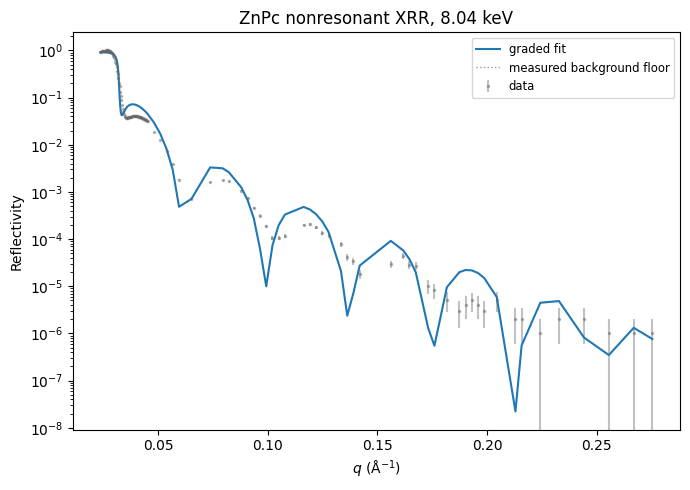

In [7]:
r_graded = graded_model(q, ENERGY_EV).s

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(q, r, yerr=r_err, fmt=".", ms=3, alpha=0.4, color="0.4", label="data")
ax.plot(q, r_graded, color="C0", lw=1.5, label="graded fit")
ax.axhline(BKG_ESTIMATE, color="0.6", ls=":", lw=1, label="measured background floor")
ax.set_yscale("log")
ax.set_xlabel(r"$q$ ($\mathrm{\AA}^{-1}$)")
ax.set_ylabel("Reflectivity")
ax.legend(fontsize="small")
ax.set_title(f"ZnPc nonresonant XRR, {ENERGY_EV / 1000:.2f} keV")
fig.tight_layout()
plt.show()

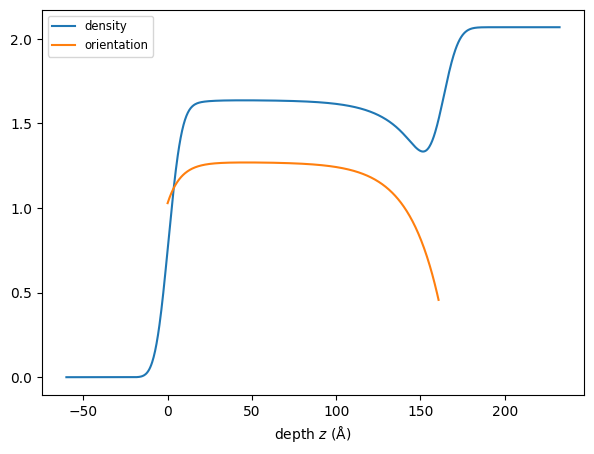

In [8]:
graded_model.structure.plot.param("orientation|density", roughness=True, pad=60.0)
plt.savefig("graded_orientation_density.png")
plt.show()

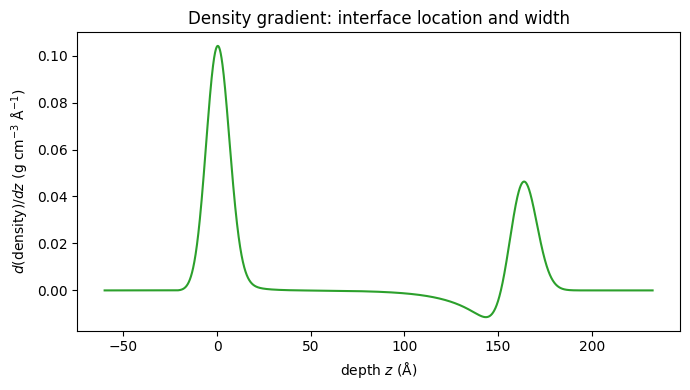

In [9]:
z_grad = graded_model.structure.depth_grid(num_points=4000, pad=60.0)
_, density_grad = graded_model.structure.density_profile_at(z_grad, roughness=True)
density_gradient = np.gradient(density_grad, z_grad)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z_grad, density_gradient, color="C2")
ax.set_xlabel(r"depth $z$ ($\mathrm{\AA}$)")
ax.set_ylabel(r"$d(\mathrm{density})/dz$ (g cm$^{-3}$ $\mathrm{\AA}^{-1}$)")
ax.set_title("Density gradient: interface location and width")
fig.tight_layout()
plt.savefig("graded_density_gradient.png")
plt.show()

## PRL supplemental figure

Two panels at PRL column width 3.55 in with aspect \(2.55{:}2.9\) (height \(\approx 4.04\) in). Panel (a): reflectivity. Panel (b): Nevot-Croce density with \(\tau_\mathrm{vac}\) / \(\tau_\mathrm{Si}\) markers styled as in `fig_5_graded.ipynb`.

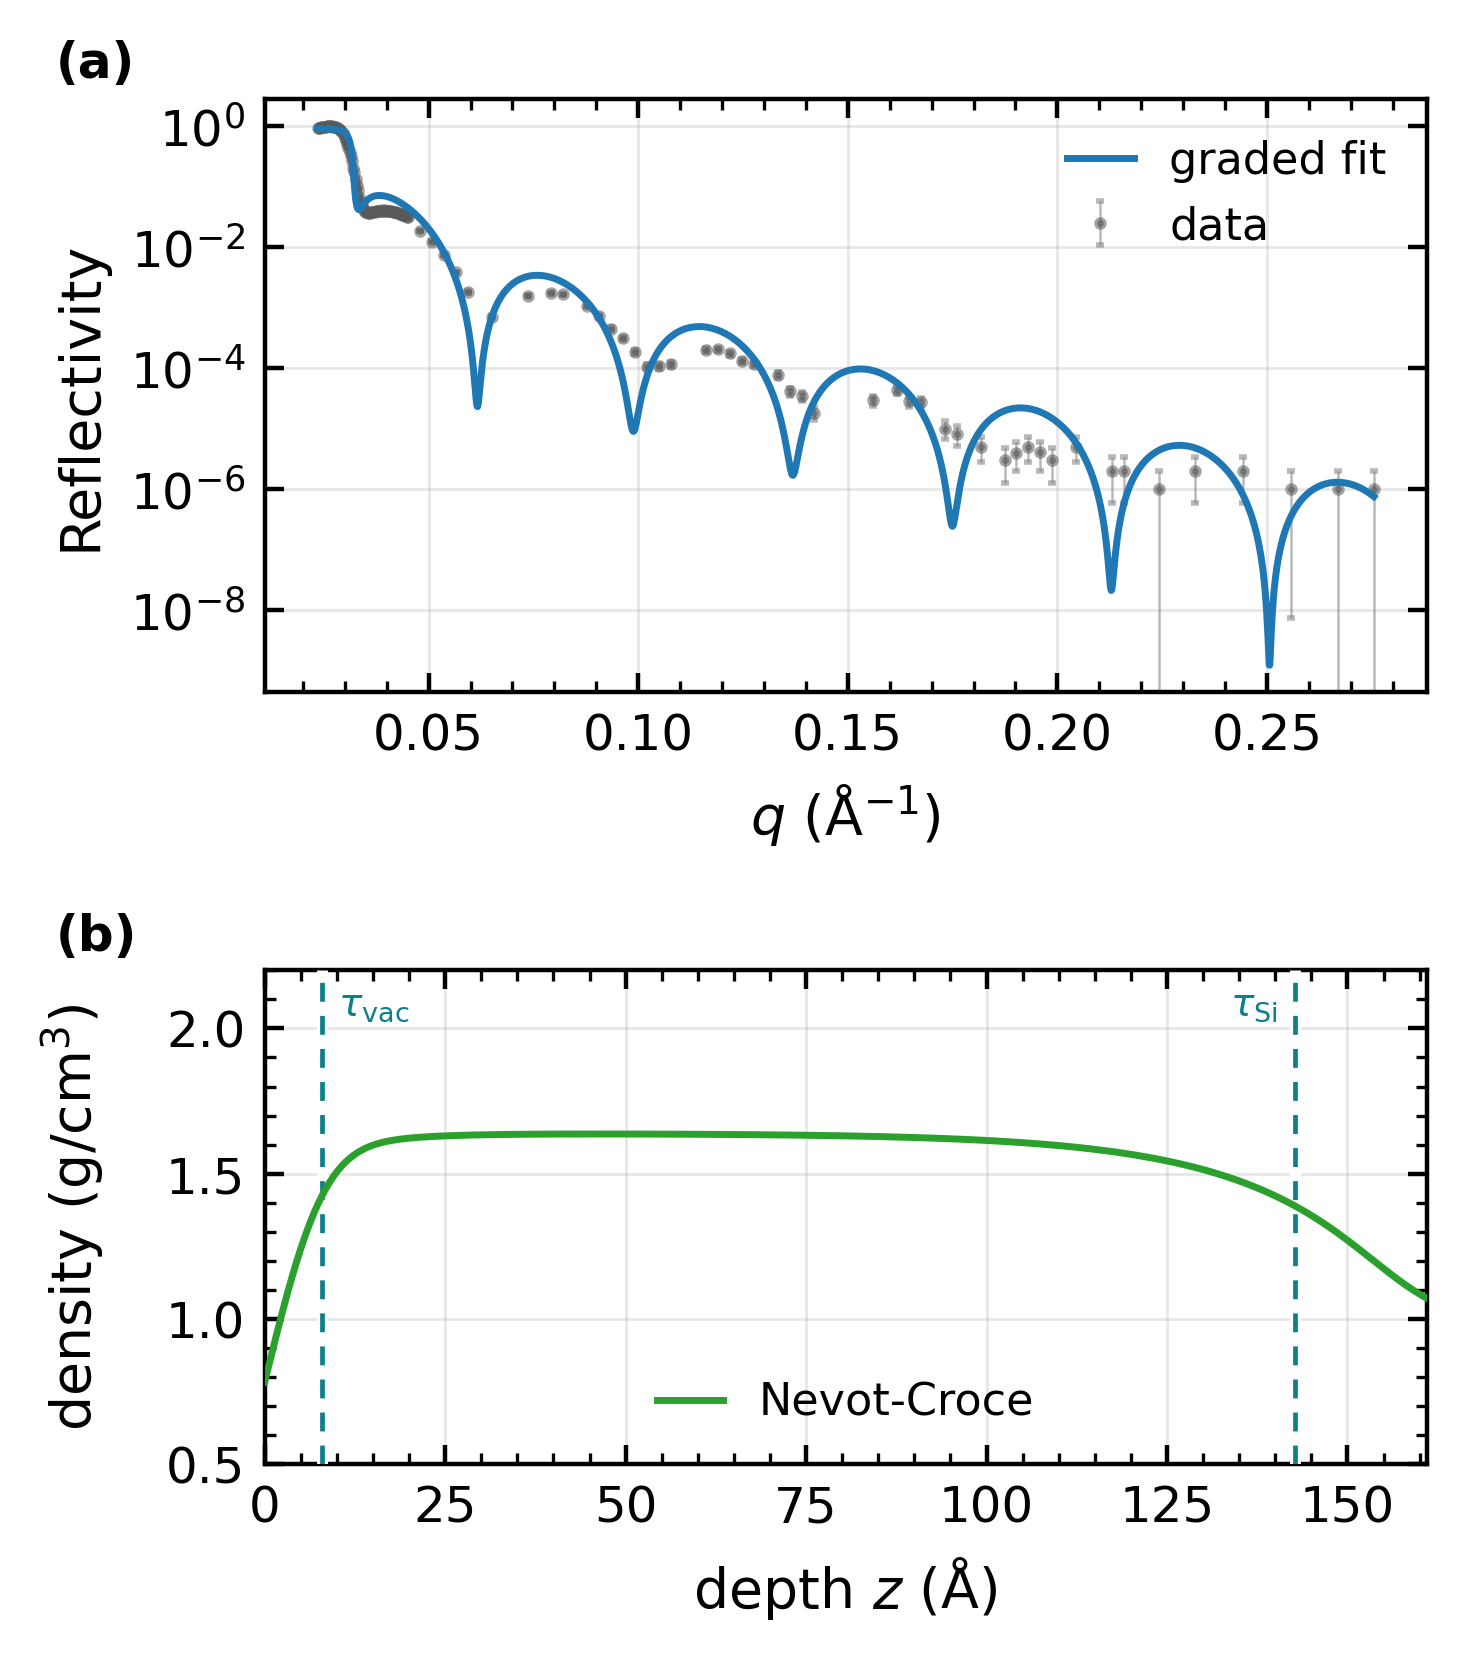

figsize = (3.55, 4.0373) in
tau_vac = 7.89 A, tau_Si anchor = 142.71 A


In [11]:
q_fine = np.linspace(q.min(), q.max(), 2000)
r_fine = graded_model(q_fine, ENERGY_EV).s


def nevot_croce_density(film, *, n_points: int = 2000, n_sigma: int = 5):
    """Book-ended density convolved with the vacuum-side Nevot-Croce term.

    Port of fig_5_graded.ipynb: analytic density convolved with a Gaussian of
    std ``film.surface_roughness``. Vacuum (0) bounds the surface side; the
    film-edge density bounds the substrate side.

    Returns
    -------
    depth, rho_sharp, rho_rough
        Arrays on ``[0, film.total_thick]``.
    """
    total = float(film.total_thick.value or 0.0)
    sigma = float(film.surface_roughness.value or 0.0)
    depth = np.linspace(0.0, total, n_points)
    rho_sharp = np.asarray(film.local_density(depth), dtype=float)
    if sigma <= 0.0:
        return depth, rho_sharp, rho_sharp.copy()

    dz = depth[1] - depth[0]
    pad = int(np.ceil(n_sigma * sigma / dz))
    z_ext = np.concatenate(
        [
            depth[0] + dz * np.arange(-pad, 0),
            depth,
            depth[-1] + dz * np.arange(1, pad + 1),
        ]
    )
    rho_ext = np.empty_like(z_ext)
    below, above = z_ext < 0.0, z_ext > total
    inside = ~(below | above)
    rho_ext[below] = 0.0
    rho_ext[inside] = np.asarray(film.local_density(z_ext[inside]), dtype=float)
    rho_ext[above] = float(film.local_density(total))

    kernel = np.exp(-0.5 * (dz * np.arange(-pad, pad + 1) / sigma) ** 2)
    kernel /= kernel.sum()
    rho_rough = np.convolve(rho_ext, kernel, mode="same")[pad : pad + n_points]
    return depth, rho_sharp, rho_rough


z_film, film_density_sharp, film_density = nevot_croce_density(graded_film)
film_total_thick = float(graded_film.total_thick.value or 0.0)
tau_vac_anchor = float(graded_film.tau_vac.value or 0.0)
tau_si_anchor = film_total_thick - float(graded_film.tau_si.value or 0.0)

PRL_WIDTH_IN = 3.55
FIG_ASPECT_W, FIG_ASPECT_H = 2.55, 2.9
FIG_HEIGHT_IN = PRL_WIDTH_IN * (FIG_ASPECT_H / FIG_ASPECT_W)

TAU_COLOR = "#0b7f8a"
TAU_LW = 0.85
TAU_LS = (0, (4, 3))

RC_OVERRIDES = {
    "text.usetex": False,
    "font.size": 10,
    "font.family": "sans-serif",
    "mathtext.fontset": "dejavusans",
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "figure.titlesize": 12,
    "grid.alpha": 0.3,
    "grid.linestyle": "-",
    "grid.linewidth": 0.5,
    "axes.grid": True,
    "axes.grid.axis": "both",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
}


def highlight_tau(ax, *, labels: bool = True) -> None:
    """Draw vacuum and Si graded-interface tau markers (fig_5 styling)."""
    for z_tau, txt, ha, dx in (
        (tau_vac_anchor, r"$\tau_\mathrm{vac}$", "left", 3),
        (tau_si_anchor, r"$\tau_\mathrm{Si}$", "right", -3),
    ):
        ax.axvline(
            z_tau,
            color="white",
            lw=TAU_LW + 1.1,
            solid_capstyle="butt",
            zorder=4,
        )
        ax.axvline(
            z_tau,
            color=TAU_COLOR,
            lw=TAU_LW,
            ls=TAU_LS,
            solid_capstyle="butt",
            zorder=5,
        )
        if labels:
            ax.annotate(
                txt,
                xy=(z_tau, 0.97),
                xycoords=("data", "axes fraction"),
                xytext=(dx, 0),
                textcoords="offset points",
                va="top",
                ha=ha,
                color=TAU_COLOR,
                fontsize=7,
            )


with plt.rc_context(RC_OVERRIDES):
    fig, (ax_fit, ax_density) = plt.subplots(
        2,
        1,
        figsize=(PRL_WIDTH_IN, FIG_HEIGHT_IN),
        dpi=400,
        layout="constrained",
        gridspec_kw={"height_ratios": (1.2, 1.0), "hspace": 0.08},
    )

    ax_fit.errorbar(
        q,
        r,
        yerr=r_err,
        fmt=".",
        ms=2.5,
        lw=0.5,
        elinewidth=0.45,
        capsize=0.8,
        alpha=0.55,
        color="0.35",
        ecolor="0.5",
        label="data",
        zorder=2,
    )
    ax_fit.plot(q_fine, r_fine, color="C0", lw=1.25, label="graded fit", zorder=10)
    ax_fit.set_yscale("log")
    ax_fit.set_xlabel(r"$q$ ($\mathrm{\AA}^{-1}$)")
    ax_fit.set_ylabel("Reflectivity")
    ax_fit.legend(frameon=False, handlelength=1.5, loc="upper right")
    ax_fit.annotate(
        "(a)",
        xy=(-0.18, 1.02),
        xycoords="axes fraction",
        fontsize=9,
        ha="left",
        va="bottom",
        fontweight="bold",
    )

    # ax_density.plot(
    #     z_film,
    #     film_density_sharp,
    #     color="C2",
    #     lw=0.8,
    #     ls=":",
    #     label="sharp",
    #     zorder=3,
    # )
    ax_density.plot(
        z_film,
        film_density,
        color="C2",
        lw=1.25,
        label="Nevot-Croce",
        zorder=6,
    )
    highlight_tau(ax_density, labels=True)
    ax_density.set_xlim(0.0, film_total_thick)
    ax_density.set_ylim(0.5, 2.2)
    ax_density.set_xlabel(r"depth $z$ ($\mathrm{\AA}$)")
    ax_density.set_ylabel(r"density (g/cm$^{3}$)")
    ax_density.legend(frameon=False, handlelength=1.5, loc="lower center", ncols=2)
    ax_density.annotate(
        "(b)",
        xy=(-0.18, 1.02),
        xycoords="axes fraction",
        fontsize=9,
        ha="left",
        va="bottom",
        fontweight="bold",
    )

    fig.align_ylabels()
    fig.savefig("graded_supplemental_fit_density.png", dpi=400)
    plt.show()

print(f"figsize = ({PRL_WIDTH_IN}, {FIG_HEIGHT_IN:.4f}) in")
print(f"tau_vac = {tau_vac_anchor:.2f} A, tau_Si anchor = {tau_si_anchor:.2f} A")